In [1]:
"""
================================================================================
                      NEURADOCK PROPRIETARY LICENSE
================================================================================
Copyright (c) 2025 NeuraDock Technology Co., Ltd. All Rights Reserved.

NOTICE:  All information contained herein is, and remains the property of 
上海脉冲基元智能科技有限公司.  if any.  The intellectual 
and technical concepts contained herein are proprietary to NeuraDock 
and may be covered by patents or patents in process, and are protected by 
trade secret or copyright law.

DISSEMINATION OF THIS INFORMATION OR REPRODUCTION OF THIS MATERIAL IS 
STRICTLY FORBIDDEN UNLESS PRIOR WRITTEN PERMISSION IS OBTAINED FROM 
NEURADOCK TECHNOLOGY CO., LTD.

TERMS OF USE:
1. Research & Demo Only: This code is strictly for internal research, 
   technical evaluation, and demonstration purposes.
2. No Commercial Use: ANY commercial use, including but not limited to 
   product development, commercial services, or integration into 
   commercial hardware/software is strictly prohibited.
3. No Redistribution: You may not share this code with third parties.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND.
================================================================================
"""


'\n================================================================================\n                      NEURADOCK PROPRIETARY LICENSE\n================================================================================\nCopyright (c) 2025 NeuraDock Technology Co., Ltd. All Rights Reserved.\n\nNOTICE:  All information contained herein is, and remains the property of \n上海脉冲基元智能科技有限公司.  if any.  The intellectual \nand technical concepts contained herein are proprietary to NeuraDock \nand may be covered by patents or patents in process, and are protected by \ntrade secret or copyright law.\n\nDISSEMINATION OF THIS INFORMATION OR REPRODUCTION OF THIS MATERIAL IS \nSTRICTLY FORBIDDEN UNLESS PRIOR WRITTEN PERMISSION IS OBTAINED FROM \nNEURADOCK TECHNOLOGY CO., LTD.\n\nTERMS OF USE:\n1. Research & Demo Only: This code is strictly for internal research, \n   technical evaluation, and demonstration purposes.\n2. No Commercial Use: ANY commercial use, including but not limited to \n   product dev

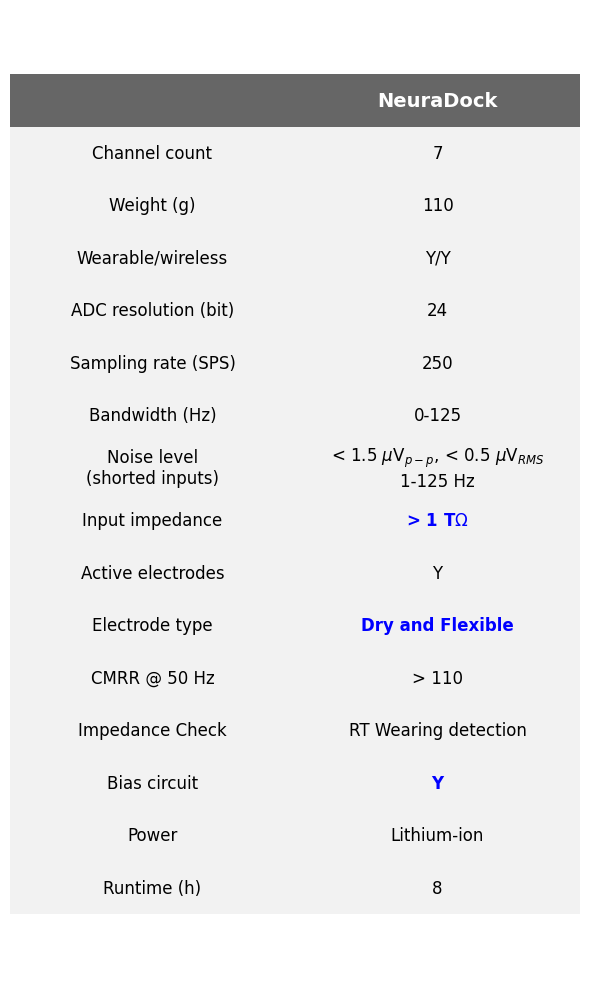

In [2]:
import matplotlib.pyplot as plt

# Data from the original "BrainTouch" column
columns = ["", "NeuraDock"]
data = [
    ["Channel count", "7"],
    ["Weight (g)", "110"],
    ["Wearable/wireless", "Y/Y"],
    ["ADC resolution (bit)", "24"],
    ["Sampling rate (SPS)", "250"],
    ["Bandwidth (Hz)", "0-125"],
    ["Noise level\n(shorted inputs)", "< 1.5 $\mu$V$_{p-p}$, < 0.5 $\mu$V$_{RMS}$\n1-125 Hz"],
    ["Input impedance", "> 1 T$\Omega$"],
    ["Active electrodes", "Y"],
    ["Electrode type", "Dry and Flexible"],
    ["CMRR @ 50 Hz", "> 110"],
    ["Impedance Check", "RT Wearing detection"],
    ["Bias circuit", "Y"],
    ["Power", "Lithium-ion"],
    ["Runtime (h)", "8"]
]

# Create figure
fig, ax = plt.subplots(figsize=(6, 10))
ax.axis('off')

# Create table
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

# Styling configuration
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2.5)  # Adjust row height

# Specific Colors
header_color = '#666666'  # Grey as requested
row_bg_color = '#f2f2f2'   # Light grey background similar to original
highlight_text_color = 'blue'

# Iterating over cells to style them
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('white') # Remove black borders, use white to blend or match background
    cell.set_linewidth(0)
    
    # Header Styling
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=14)
        cell.set_facecolor(header_color)
        if col == 0:
            cell.set_facecolor(header_color) # Make empty corner same color
    else:
        # Data Rows Styling
        cell.set_facecolor(row_bg_color)
        
        # Column 0 (Labels)
        if col == 0:
            cell.set_text_props(color='black')
        
        # Column 1 (Data) - Handle highlighting for specific rows based on original image
        if col == 1:
            content = data[row-1][1]
            # Identify rows that were blue in the original image
            if "Dry and Flexible" in content or "> 1 T" in content or (content == "Y" and data[row-1][0] == "Bias circuit"):
                 cell.set_text_props(color=highlight_text_color, weight='bold')
            else:
                cell.set_text_props(color='black')

# Adjust layout to remove whitespace
plt.tight_layout()

# Save the plot as an image
#output_path = "neuradock_table.png"
#plt.savefig("neuradock_table.png", bbox_inches='tight', dpi=300, pad_inches=0.1)

Paradigm 1: Signal quality of eyes open/closed in natural state
Data shape: (7, 13210)
Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 52 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


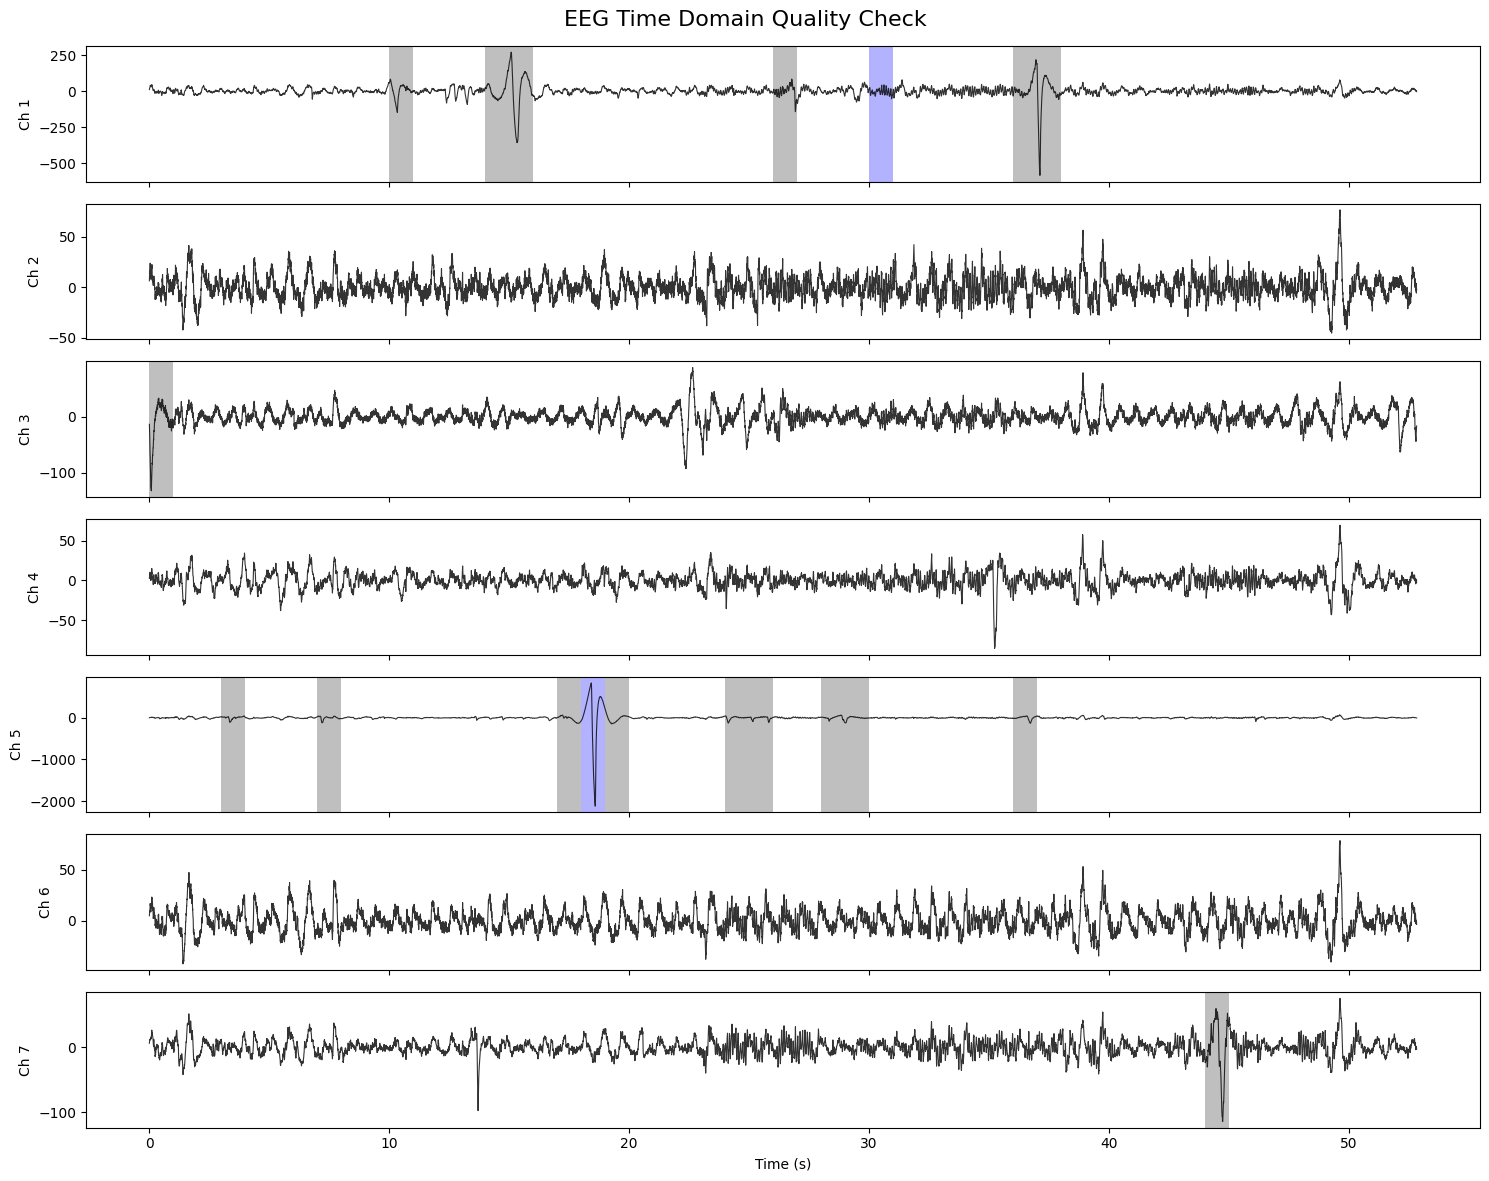

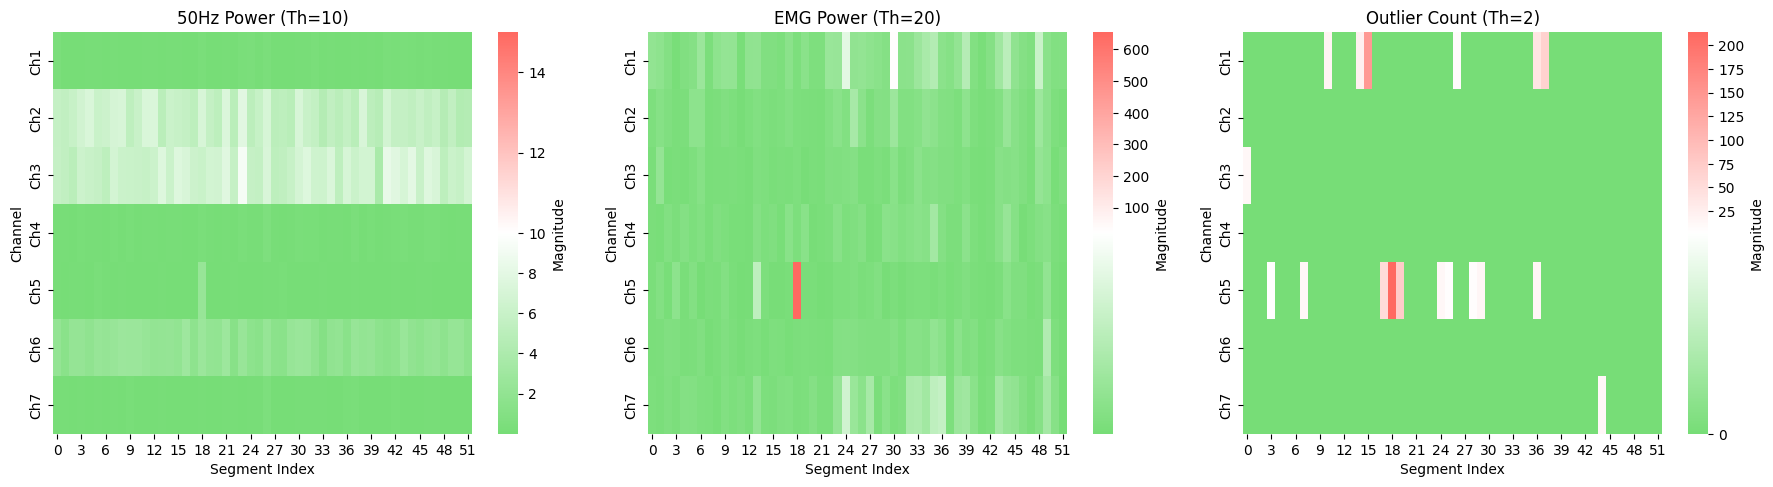

Gray: outliers; Blue: EMG; Red: powerline noise
After running this step, you can clearly see the overall signal quality of this data. If the heatmap is mostly green, the signal quality is good.
Please note that eeg_quality_check has three key noise judgment thresholds, which can be increased or decreased according to your use case.In thresh = [10, 20, 2], the three values correspond to 50Hz threshold, EMG threshold, and outlier count. 


In [3]:
from Neuradock_library import text2data_bluetooth, eeg_quality_check, clean_eeg_data
from Neuradock_library import analyze_alpha_and_plot_eeg_group
print('Paradigm 1: Signal quality of eyes open/closed in natural state')
# 1. Read data
bluetooth_data = text2data_bluetooth('open_closed_eye2.txt')
print("Data shape:", bluetooth_data.shape)

# 2. Quality check
metrics = eeg_quality_check(bluetooth_data, fs = 250)
print("Gray: outliers; Blue: EMG; Red: powerline noise")
print("After running this step, you can clearly see the overall signal quality of this data. If the heatmap is mostly green, the signal quality is good.")
print("Please note that eeg_quality_check has three key noise judgment thresholds, which can be increased or decreased according to your use case." \
        "In thresh = [10, 20, 2], the three values correspond to 50Hz threshold, EMG threshold, and outlier count. ")

In [4]:
thresh = [10, 20,  2] # Neuradock factory parameter settings
clean_data, points_to_keep, info = clean_eeg_data(bluetooth_data, metrics, thresh, seg_len=250, bad_ch_ratio=0.4)


Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 13210 -> cleaned 8710
Information retention rate: 65.93%


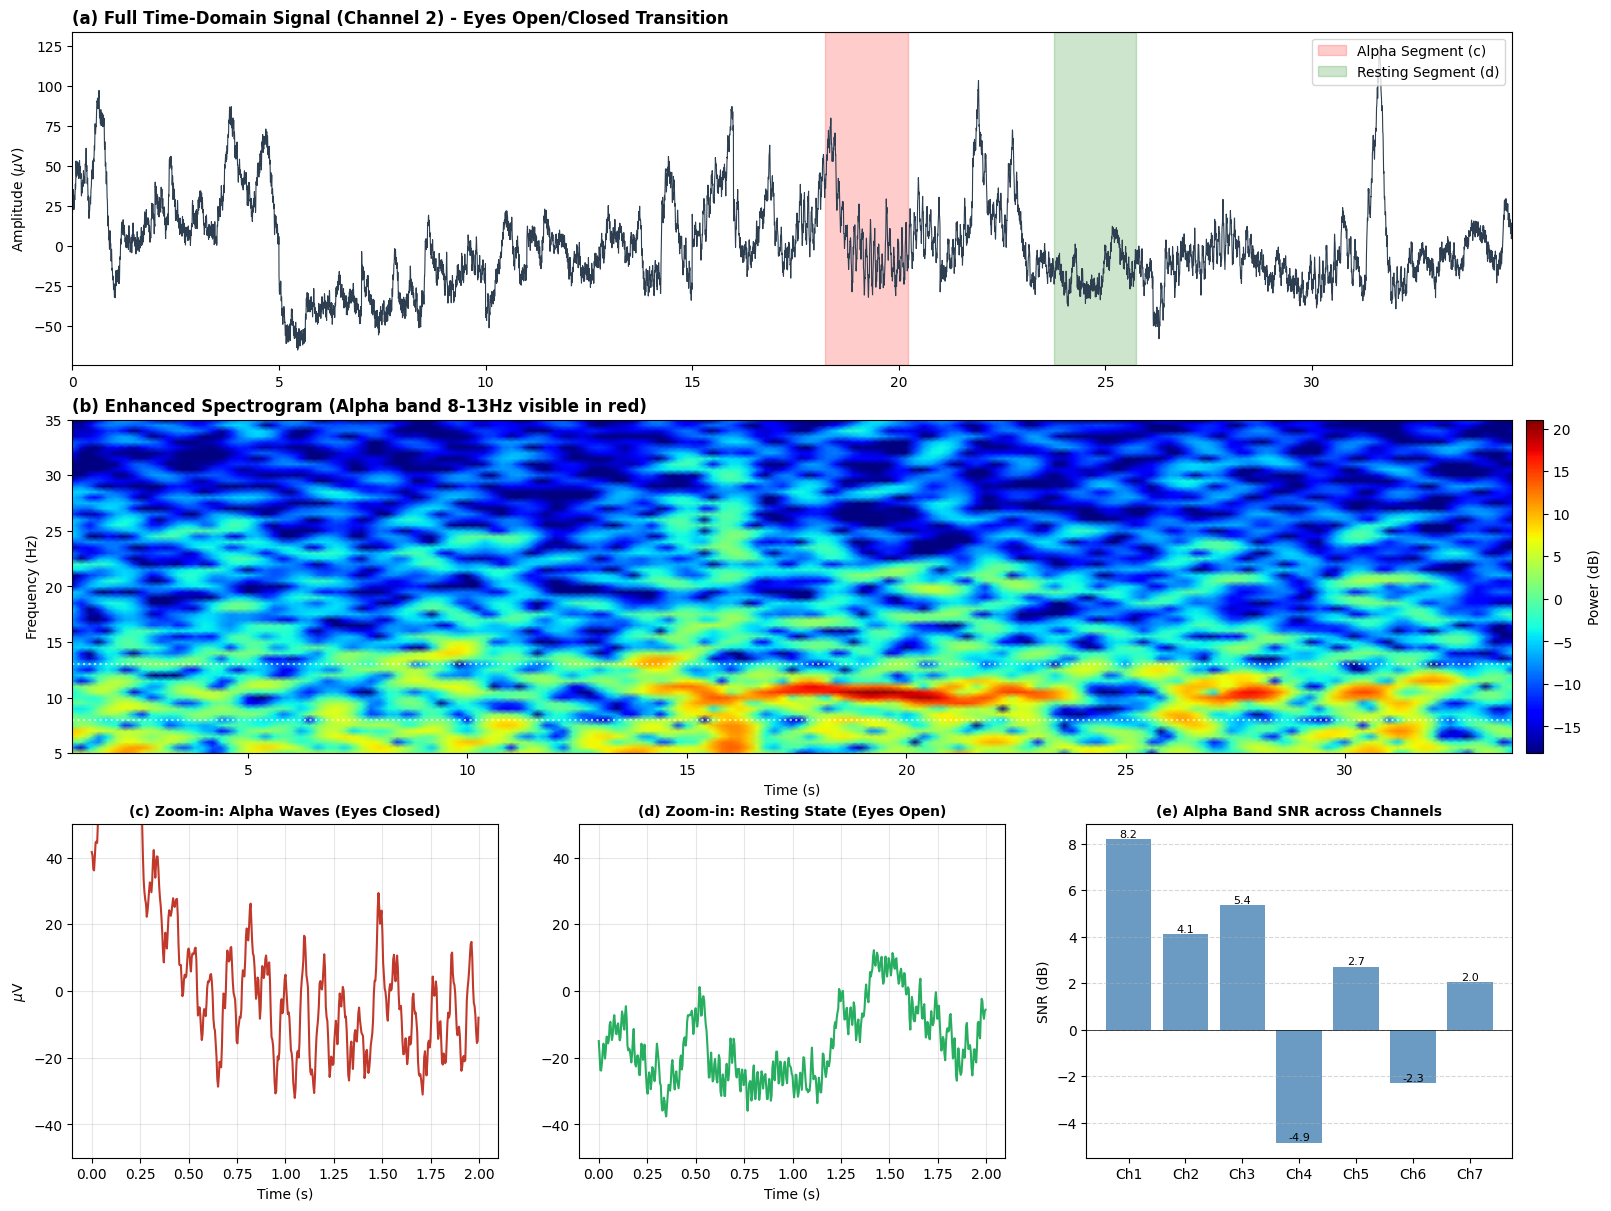


[NeuraDock Signal Analysis Report]
1. Phenomenon capture (Alpha Blocking): 
   - Eyes closed stage (Eyes Closed, Red Zone): spectrogram (b) shows significant high-energy red blocks at 8-13Hz (Alpha band), time domain plot (c) shows clear sinusoidal waveform.
   - Eyes open stage (Eyes Open, Green Zone): Alpha waves are rapidly suppressed (desynchronized).

2. Signal quality (Signal Quality):
   - Despite using dry electrodes, Channel 1 has an SNR as high as 8.2 dB in the Alpha band (Fig. e).



In [5]:
analyze_alpha_and_plot_eeg_group(clean_data, fs=250, show_channel=1)
print(f"""
[NeuraDock Signal Analysis Report]
============================================================
1. Phenomenon capture (Alpha Blocking): 
   - Eyes closed stage (Eyes Closed, Red Zone): spectrogram (b) shows significant high-energy red blocks at 8-13Hz (Alpha band), time domain plot (c) shows clear sinusoidal waveform.
   - Eyes open stage (Eyes Open, Green Zone): Alpha waves are rapidly suppressed (desynchronized).

2. Signal quality (Signal Quality):
   - Despite using dry electrodes, Channel 1 has an SNR as high as 8.2 dB in the Alpha band (Fig. e).
============================================================
""")

Paradigm 2: ERD cognitive load
Read brain data collected during subject's resting and task states
Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 132 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


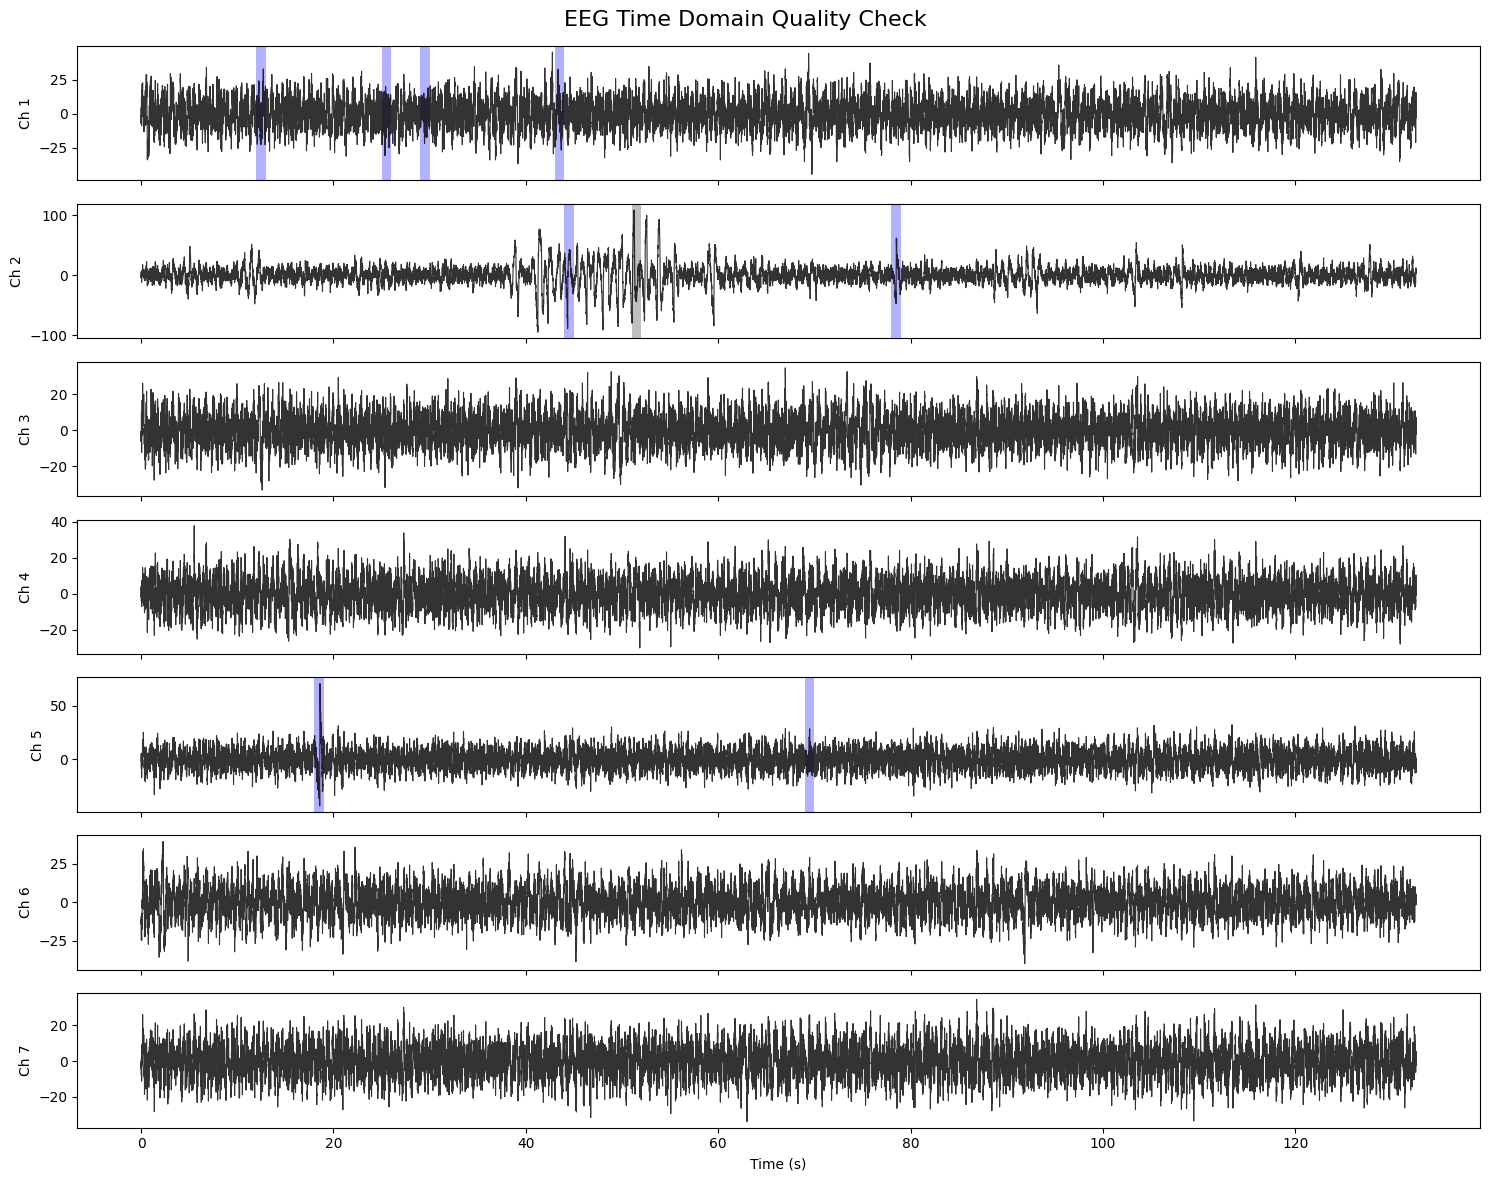

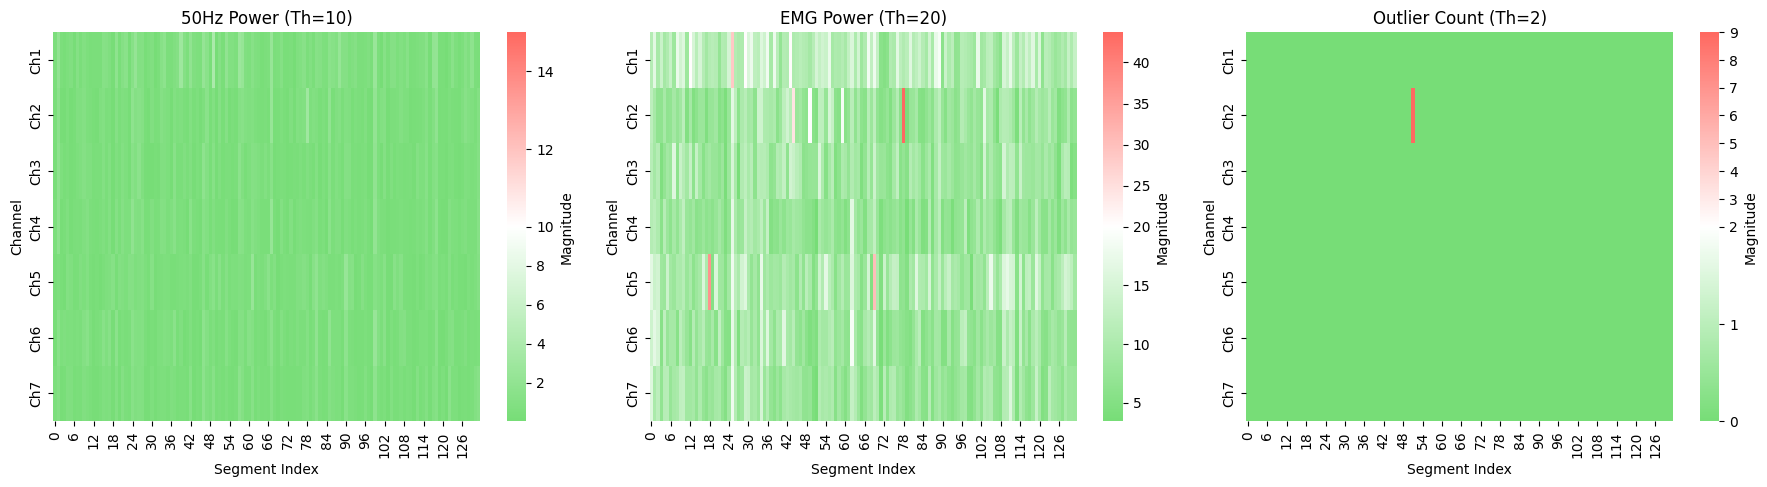

Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 33145 -> cleaned 30895
Information retention rate: 93.21%
Applying bandpass filter (1-100Hz)...
Start processing data: 7 channels, 153 segments (250 points per segment)...


c:\Users\36254\anaconda3\envs\neuradock\Lib\site-packages\scipy\signal\_spectral_py.py:600: UserWarning: nperseg = 2048 is greater than input length  = 250, using nperseg = 250
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


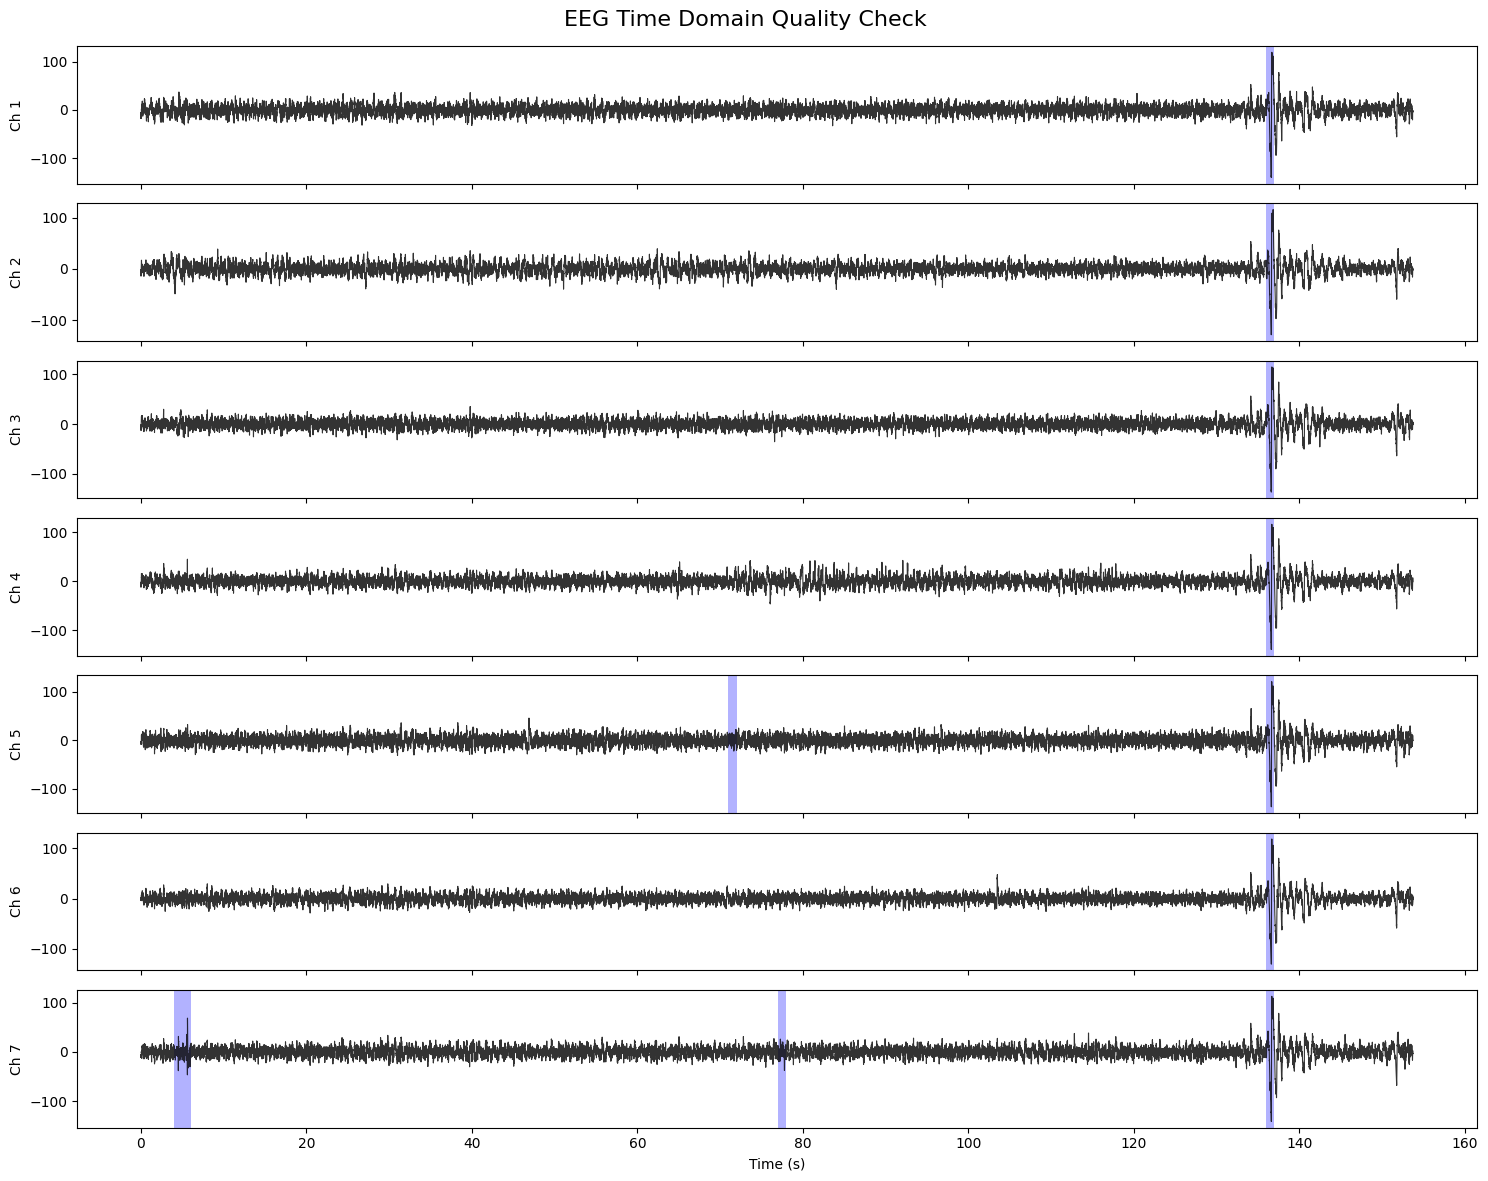

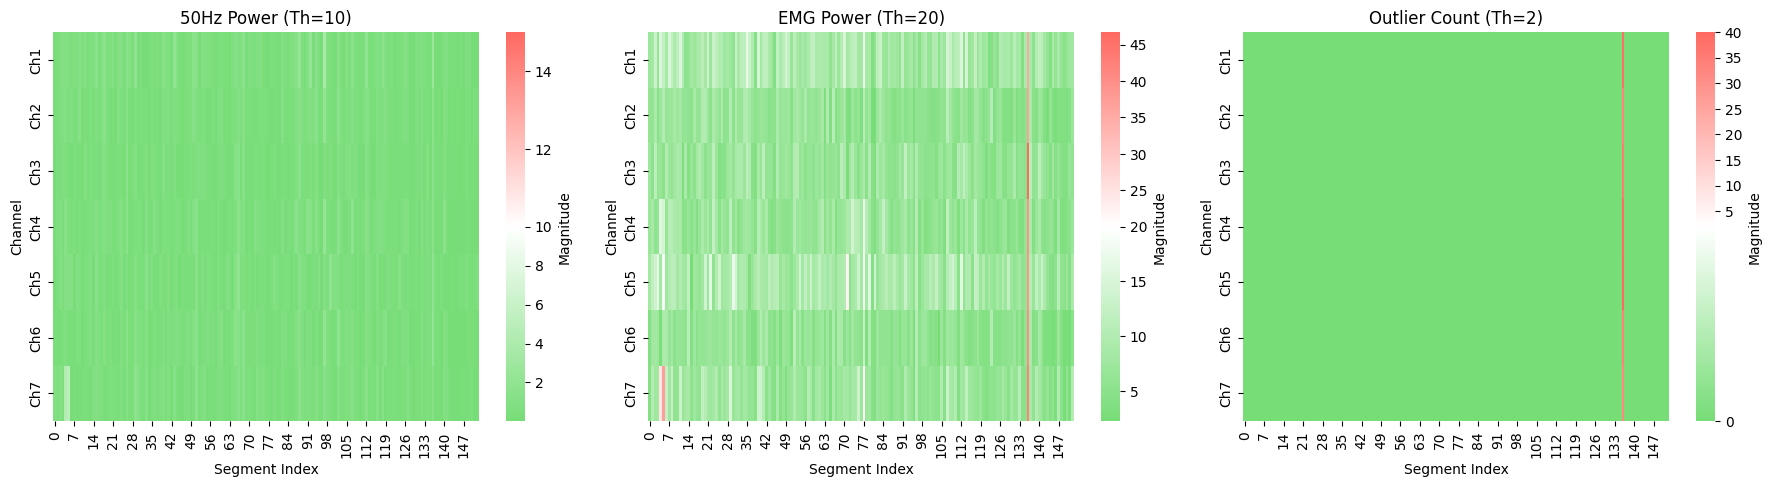

Detection results:
  - Bad channel indices (noise ratio > 40.0%): []
  - Good channel indices: [0 1 2 3 4 5 6]
Data cleaning complete: original length 38435 -> cleaned 37185
Information retention rate: 96.75%


In [7]:
print('Paradigm 2: ERD cognitive load')
print("Read brain data collected during subject's resting and task states")

# 1. Read data and signal preprocessing
bluetooth_data = text2data_bluetooth('rest_20251024160452_2m12s.txt')
metrics = eeg_quality_check(bluetooth_data, fs = 250)
thresh = [10, 20,  2] # Neuradock factory parameter settings
clean_data_rest, points_to_keep, info = clean_eeg_data(bluetooth_data, metrics, thresh, seg_len=250, bad_ch_ratio=0.4)

bluetooth_data = text2data_bluetooth('task_20251024160748_2m33s.txt')
metrics = eeg_quality_check(bluetooth_data, fs = 250)
thresh = [10, 20,  2] # Neuradock factory parameter settings
clean_data_task, points_to_keep, info = clean_eeg_data(bluetooth_data, metrics, thresh, seg_len=250, bad_ch_ratio=0.4)

In [8]:
from scipy.signal import welch
import numpy as np
# Calculate alpha wave channel energy
print(f"""
[Paradigm 2: Capturing the brain's "busy moment" — ERD phenomenon observation]
========================================================================
1. Experimental core (The Core Question): 
   - Can our NeuraDock device distinguish whether your brain is "slacking off (Resting)" or "working hard (Task)"?
   - This paradigm will give you an intuitive feel for the electrophysiological characteristics when the brain switches cognitive load.

2. Quick understanding of principles (Intuitive Explanation):
   - Resting state (Resting State) = brain's "choir mode":
     When you relax and daydream, neurons act like a well-trained choir, emitting 8-13Hz Alpha wave rhythms in unison (high energy).
   
   - Task state (Task State) = brain's "workgroup mode":
     Once you start processing visual tasks or calculations, the choir disbands! Neurons become busy individually, and Alpha waves are instantly disrupted and suppressed.
     This phenomenon is known in neuroscience as **ERD (Event-Related Desynchronization)**, i.e., "event-related desynchronization".
========================================================================
""")
alpha_power_rest = []

for i in range(7):
    freqs, psd = welch(clean_data_rest[i],250,nperseg=2048)
    alpha_band = (8, 13)

    # Find indices of all frequency points within Alpha band
    idx_alpha = np.where((freqs >= alpha_band[0]) & (freqs <= alpha_band[1]))[0]
    # Integrate PSD in Alpha band using Simpson's rule to obtain total power
    # We need to provide PSD values and corresponding frequency values for this band
    alpha_power = np.mean(psd[idx_alpha])
    
    # Add calculated Alpha power to list
    alpha_power_rest.append(alpha_power)

alpha_power_data1 = np.array(alpha_power_rest)

print("Calculate task-state alpha wave channel energy")
alpha_power_task = []
for i in range(7):
    freqs, psd = welch(clean_data_task[i],250,nperseg=2048)
    alpha_band = (8, 13)

    # Find indices of all frequency points within Alpha band
    idx_alpha = np.where((freqs >= alpha_band[0]) & (freqs <= alpha_band[1]))[0]
    # Integrate PSD in Alpha band using Simpson's rule to obtain total power
    # We need to provide PSD values and corresponding frequency values for this band
    alpha_power = np.mean(psd[idx_alpha])
    
    # Add calculated Alpha power to list
    alpha_power_task.append(alpha_power)

alpha_power_data2 = np.array(alpha_power_task)
print("Calculate alpha wave energy change in brain after vs before task")
alpha_power_data = alpha_power_data2 - alpha_power_data1


[Paradigm 2: Capturing the brain's "busy moment" — ERD phenomenon observation]
1. Experimental core (The Core Question): 
   - Can our NeuraDock device distinguish whether your brain is "slacking off (Resting)" or "working hard (Task)"?
   - This paradigm will give you an intuitive feel for the electrophysiological characteristics when the brain switches cognitive load.

2. Quick understanding of principles (Intuitive Explanation):
   - Resting state (Resting State) = brain's "choir mode":
     When you relax and daydream, neurons act like a well-trained choir, emitting 8-13Hz Alpha wave rhythms in unison (high energy).

   - Task state (Task State) = brain's "workgroup mode":
     Once you start processing visual tasks or calculations, the choir disbands! Neurons become busy individually, and Alpha waves are instantly disrupted and suppressed.
     This phenomenon is known in neuroscience as **ERD (Event-Related Desynchronization)**, i.e., "event-related desynchronization".

Calculat

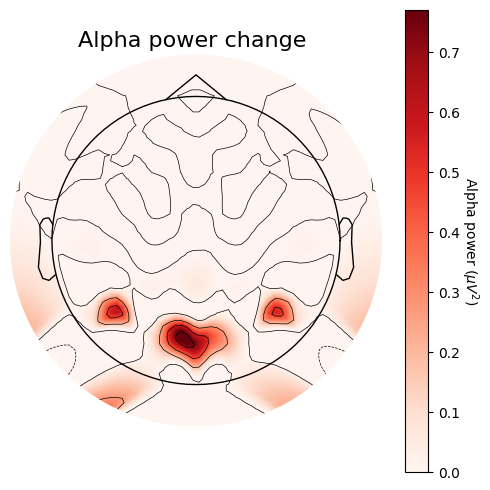


[NeuraDock Topographic Analysis: Alpha Power Modulation]
1. Precise localization (Spatial Localization):
   - The heatmap shows Alpha wave energy is highly concentrated in the occipital (Occipital) and parietal (Parietal) regions.
   - Core response channels: Oz, O1, O2, PO3, PO4, T5, T6.

2. Physiological mechanism interpretation (Physiological Interpretation):
   - Red highlighted area (High Power): represents Alpha rhythm synchronization (Synchronization) in quiet/eyes-closed state.
   - Task state difference: when the subject performs visual tasks, the energy in this region undergoes significant "desynchronization" (Alpha Blocking), proving that the system accurately captures cognitive load changes when the brain processes visual information.

3. Conclusion (Conclusion):
   - The smoothness and strong localization of the topographic map indicate that the preprocessed dry electrode signal has extremely high consistency, not only distinguishing states but also providing core feature

In [9]:
import mne
# : Define electrode system and data ---
montage_name = 'GSN-HydroCel-128'
montage = mne.channels.make_standard_montage(montage_name)
full_info = mne.create_info(ch_names=montage.ch_names, sfreq=250, ch_types='eeg')
full_info.set_montage(montage)

user_data_1020 = {
    'PO4': alpha_power_data[0], 'O2':  alpha_power_data[1], 'T6':  alpha_power_data[2], 'Oz':  alpha_power_data[3],
    'T5':  alpha_power_data[4], 'O1':  alpha_power_data[5], 'PO3': alpha_power_data[6]
}
channel_map_1020_to_E = {
    'O2': 'E83', 'PO4':  'E76', 'T6':  'E96', 'Oz':  'E75',
    'T5':  'E58', 'PO3':  'E71', 'O1': 'E70'
}


user_data_E_names = {channel_map_1020_to_E[name]: value for name, value in user_data_1020.items()}


# --- Step 3: Map data (same as before) ---
full_ch_names = full_info['ch_names']
full_data_array = np.zeros(len(full_ch_names))
#full_data_array = np.full(len(full_ch_names), np.nan)  # Use NaN instead of 0
for ch_name, value in user_data_E_names.items():
    idx = full_ch_names.index(ch_name)
    full_data_array[idx] = value


# --- Step 4: Draw topographic map and custom crop ---
fig, ax = plt.subplots(figsize=(6, 6))

names_list = [''] * len(full_ch_names)

# 2. Iterate over our channel mapping dictionary
for standard_name, e_name in channel_map_1020_to_E.items():
    try:
        # Find index of 'E' name in full list
        idx = full_ch_names.index(e_name)
        # At this index, fill in the standard name we want to display

        names_list[idx] = standard_name
    except ValueError:
        # This warning is almost never triggered
        print(f"Warning: mapped channel '{e_name}' not found in info object.")
im, cn = mne.viz.plot_topomap(
    full_data_array,
    full_info,
    axes=ax,
    show=False,
    extrapolate='box',
    image_interp='cubic',
    contours=6,
    names=names_list,
    sensors=False,
    #vlim=(0,5)
)

# Step 6: Add colorbar and title
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Alpha power ($μV^2$)', rotation=270, labelpad=15)
ax.set_title('Alpha power change ', fontsize=16)
plt.show()
print(f"""
[NeuraDock Topographic Analysis: Alpha Power Modulation]
============================================================
1. Precise localization (Spatial Localization):
   - The heatmap shows Alpha wave energy is highly concentrated in the occipital (Occipital) and parietal (Parietal) regions.
   - Core response channels: Oz, O1, O2, PO3, PO4, T5, T6.

2. Physiological mechanism interpretation (Physiological Interpretation):
   - Red highlighted area (High Power): represents Alpha rhythm synchronization (Synchronization) in quiet/eyes-closed state.
   - Task state difference: when the subject performs visual tasks, the energy in this region undergoes significant "desynchronization" (Alpha Blocking), proving that the system accurately captures cognitive load changes when the brain processes visual information.
   
3. Conclusion (Conclusion):
   - The smoothness and strong localization of the topographic map indicate that the preprocessed dry electrode signal has extremely high consistency, not only distinguishing states but also providing core feature input for subsequent complex tasks.
============================================================
""")